In [1]:
using LinearAlgebra
using Plots

Base.@kwdef struct Params
    # geometry
    L::Float64 = 1.0
    N::Int = 512
    dx::Float64 = L/(N-1)

    # time
    T::Int = 200
    dt::Float64 = 1e-2

    # phase field
    l::Float64 = 0.01
    kappa::Float64 = 1e-6

    # material
    ν::Float64 = 0.3
    A::Float64 = 1.0
    n::Int = 3
    C2::Float64 = 1.0
    C3::Float64 = 1.0

    # numerics
    tol::Float64 = 1e-6
    max_iter::Int = 30

    # critical energy for damage
    psi_crit::Float64 = 1e-2

    savefile::String = "viscoelastic_1d.jls"
end

Params

In [2]:
# ============================================================
# Material properties
# ============================================================

# Young's modules tuned by Poisson ratio ν to satisfy mass balance
E(p) = 2*(1+p.ν)^2/(1-p.ν)

# Lame Parameters
λ(p) = E(p)*p.ν / ((1+p.ν)*(1-2p.ν))
μ(p) = E(p)/(2*(1+p.ν))


# ============================================================
# Utilities
# ============================================================

# Gaussian
function gaussian(x, x0, width, amp)
    return amp * exp.(-(x.-x0).^2 ./ (2*width^2))
end

# ⟨x⟩_+
positive(x) = 0.5 * (x + abs(x))

# centred FD with forward/backward on ends
function DfDx(f::Vector, p::Params)
    N = p.N
    dx = p.dx
    fx = zeros(N)
    fx[1] = (f[2]-f[1])/dx
    for i in 2:N-1
        fx[i] = (f[i+1]-f[i-1])/(2dx)
    end
    fx[N] = (f[N]-f[N-1])/dx
    return fx
end

# centred FD with forward/backward on ends
function DfDxx(f::Vector, p::Params)
    N = p.N
    dx = p.dx
    idx = 1/dx
    fxx = zeros(N)
    fxx[1] = (2*f[1]-5*f[2]+4*f[3]-f[4])*idx^2
    for i in 2:N-1
        fxx[i] = (f[i+1]-2*f[i]+f[i-1])*idx^2
    end
    fxx[N] = (2*f[N]-5*f[N-1]+4*f[N-2]-f[N-3])*idx^2
    return fxx
end

# midpoint
# stagav(f)_[i]=f_{i+1/2}, stagav(f)_[i-1]=f_{i-1/2} 
stagav(f) = 0.5 .* (f[1:end-1] .+ f[2:end])

# degradation function
g(d,p) = (1 .- d).^2 .+ p.kappa

# ============================================================
# Effective stiffness K̄(d, a_x), 
# with a_x = u_x - w_x (elastic displacement)
# ============================================================

function Kbar(ax, d, p)
    K0 = λ(p)/2 + μ(p)/3 + 4/3
    gval = g(d,p)
    K = similar(ax)
    for i in eachindex(d)
        if ax[i] > 0
            K[i] = 2*gval[i]*K0
        else
            K[i] = 2*K0
        end
    end
    return K
end

# ============================================================
# Glen viscosity coefficients
# ============================================================

function Fcoef(ax, d, p)
    gval = g(d,p)
    n = p.n
    A = p.A
    C2 = p.C2
    F = similar(d)
    for i in eachindex(d)
        if ax[i] > 0
            F[i] = 2^((1+n)/2)*A*
                   (C2*(16/9 + 8/(9*gval[i])))^n
        else
            F[i] = 2^((1+n)/2)*A*
                   (C2*(8/9 + 16/(9*gval[i])))^n
        end
    end
    return F
end


function Gcoef(ax, p)
    n = p.n
    return ax.^(n-1)
end

Gcoef (generic function with 1 method)

In [ ]:
function get_matrix(u_old, w_old, d, ubarL, ubarR, p::Params)
    N  = p.N
    dx = p.dx
    idx = 1/dx
    dt = p.dt
    n = p.n

    u = copy(u_old)
    w = copy(w_old)

    #for iter in 1:p.max_iter
        # elastic strain
        a = u .- w
        ax = DfDx(a,p)

        # coefficients
        K = Kbar(ax,d,p)
        Kmid = stagav(K)

        F = Fcoef(ax,d,p)
        G = Gcoef(ax,p)
        Fmid = stagav(F)
        Gmid = stagav(G)
        Fx = DfDx(F, p)
        #Gx = DfDx(G, p)
        Gx = (n-1)*ax.^(n-2) .*DfDxx(a,p)

        # --------------------------------------------------
        # Allocate blocks
        # --------------------------------------------------
        A = zeros(N,N)
        B = zeros(N,N)
        C = zeros(N,N)
        D = zeros(N,N)

        a = zeros(N)
        c = zeros(N)

        # --------------------------------------------------
        # Boundary conditions (u)
        # --------------------------------------------------
        A[1,1] = 1.0
        a[1]   = ubarL

        A[N,N] = 1.0
        a[N]   = ubarR

        # --------------------------------------------------
        # Boundary conditions (w)
        # --------------------------------------------------
        D[1,1] = 1.0
        #c[1]   = w_old[1]/(1+dt*F[1]) + ubarL*dt*F[1]/(1+dt*F[1])
        #c[1] = w_old[1] + dt*F[1]*G[1]*(u[1]-w[1])
        c[1] = 0.0
        D[N,N-1] = -1.0
        D[N,N] = 1.0
        c[N] = 0.0
        #c[N]   = w_old[end]/(1+dt*F[end]) + ubarR*dt*F[end]/(1+dt*F[end])
        #c[N] = w_old[N] + dt*F[N]*G[N]*(u[N]-w[N])

        # # Neumann, using the viscosity eq. and front/backward FD on ends
        #C[1,1] = (-Fmid[1]*Gmid[1]*dt-F[1]*Gx[1]*dt*dx-Fx[1]*G[1]*dt*dx)*idx
        #C[1,2] = (Fmid[1]*Gmid[1]*dt)*idx
        #D[1,1] = (Fmid[1]*Gmid[1]*dt + F[1]*Gx[1]*dt*dx + Fx[1]*G[1]*dt*dx)*idx
        #D[1,2] = (-Fmid[1]*Gmid[1]*dt)*idx
        #c[1]   = 0.0 

        # # the last mid points has index N-1; it is shorter by 1 from the full grid
        # C[N,N-1] = (-Fmid[N-1]*Gmid[N-1]*dt)*idx
        # C[N,N] = (Fmid[N-1]*Gmid[N-1]*dt-F[N]*Gx[N]*dt*dx-Fx[N]*G[N]*dt*dx)*idx
        # D[N,N-1] = (Fmid[N-1]*Gmid[N-1]*dt)*idx
        # D[N,N] = (-Fmid[N-1]*Gmid[N-1]*dt+F[N]*Gx[N]*dt*dx+Fx[N]*G[N]*dt*dx)*idx
        # c[N]   = 0.0

        # C[N,N-1] = 0.5+Fmid[N-1]*Gmid[N-1]*dt
        # C[N,N] = 0.0
        # D[N,N-1] = -1-Fmid[N-1]*Gmid[N-1]*dt
        # D[N,N] = 1+Fmid[N-1]*Gmid[N-1]-F[N]*Gx[N]*dt*dx-Fx[N]*G[N]*dt*dx
        # c[N]   = -0.5*(ubarR + w_old[N])+0.5*w_old[N-1]-Fmid[N-1]*Gmid[N-1]*dt*ubarR + F[N]*Gx[N]*dt*dx*ubarR + Fx[N]*G[N]*dt*dx*ubarR

        # --------------------------------------------------
        # Interior nodes
        # ---------------------------------------------------
        for i in 2:N-1
            im = i-1
            ip = i+1

            # m=minus=i-1/2, p=plus=i+1/2
            km = Kmid[i-1]
            kp = Kmid[i]
            Fm = Fmid[i-1]
            Fp = Fmid[i]
            Gm = Gmid[i-1]
            Gp = Gmid[i]

            # ===== Momentum equation =====
            A[i,im] =  km#*idx^2
            A[i,i]  = -(km+kp)#*idx^2
            A[i,ip] =  kp#*idx^2

            B[i,im] = -km#*idx^2
            B[i,i]  =  (km+kp)#*idx^2
            B[i,ip] = -kp#*idx^2

            # ===== Viscosity equation =====
            C[i,im] =  0.5*dt*Fm*Gm
            C[i,i]  = -dt*(0.5*Fp*Gp-0.5*Fm*Gm-dx*(Fx[i]*G[i]+F[i]*Gx[i]))
            C[i,ip] = -0.5*dt*Fp*Gp

            D[i,im] = -0.5*(1 + dt*Fm*Gm)
            D[i,i]  = -dt*(0.5*Fp*Gp-0.5*Fm*Gm-dx*(Fx[i]*G[i]+F[i]*Gx[i]))
            D[i,ip] =  0.5*(1 + dt*Fp*Gp)

            # RHS
            c[i] = (w_old[ip] - w_old[im]) / 2
        end

        # --------------------------------------------------
        # Assemble full system
        # --------------------------------------------------
        M = [A  B;
             C  D]

        rhs = [a; c]

    #     sol = M \ rhs

    #     u_new = sol[1:N]
    #     w_new = sol[N+1:end]

    #     res = maximum(abs.(u_new-u)) + maximum(abs.(w_new-w))
    #     u .= u_new
    #     w .= w_new

    #     if res < p.tol
    #         break
    #     end
    # end

    return M, rhs, A, B, C, D
end

get_matrix (generic function with 1 method)

In [66]:
p = Params()
x = range(0,p.L,p.N)

u = 0.1*gaussian(x, p.L/2, 0.05, 0.2)#zeros(p.N)
w = 0.01*gaussian(x, p.L/2, 0.05, 0.2)#zeros(p.N)
d = 0.1*gaussian(x, p.L/2, 0.05, 0.2)#0.01*rand(p.N)
H = zeros(p.N)

512-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [67]:
ubarL, ubarR = (0.0, 0.1) 
M, rhs, A, B, C, D = get_matrix(u,w,d,ubarL,ubarR,p)

([1.0 0.0 … 0.0 0.0; 6.69048288095238 -13.38096576190476 … 0.0 0.0; … ; 0.0 0.0 … -3.214131359630391e-43 0.5; 0.0 0.0 … -11.0 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  -4.74396028243509e-24, -3.2633152028062556e-24, -2.2413256814799502e-24, -1.5370179192155847e-24, -1.0524003174966922e-24, -7.194674360481406e-25, -4.910995094986741e-25, -3.3470029846691524e-25, -2.27756611779047e-25, 0.0], [1.0 0.0 … 0.0 0.0; 6.69048288095238 -13.38096576190476 … 0.0 0.0; … ; 0.0 0.0 … -13.38095238095238 6.69047619047619; 0.0 0.0 … 0.0 1.0], [0.0 0.0 … 0.0 0.0; -6.69048288095238 13.38096576190476 … 0.0 0.0; … ; 0.0 0.0 … 13.38095238095238 -6.69047619047619; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 3.443615020318302e-43 3.214134573761751e-43 … 0.0 0.0; … ; 0.0 0.0 … -3.214131359630391e-43 -3.4436115767067242e-43; 0.0 0.0 … 0.0 0.0], [1.0 0.0 … 0.0 0.0; -0.5 3.214134573761751e-43 … 0.0 0.0; … ; 0.0 0.0 … -3.214131359630391e-43 0.5; 0.0 0.0 … -11.0 1.0])

In [68]:
D

512×512 Matrix{Float64}:
  1.0   0.0           0.0          …   0.0           0.0          0.0
 -0.5   3.21413e-43   0.5              0.0           0.0          0.0
  0.0  -0.5           6.05441e-43      0.0           0.0          0.0
  0.0   0.0          -0.5              0.0           0.0          0.0
  0.0   0.0           0.0              0.0           0.0          0.0
  0.0   0.0           0.0          …   0.0           0.0          0.0
  0.0   0.0           0.0              0.0           0.0          0.0
  0.0   0.0           0.0              0.0           0.0          0.0
  0.0   0.0           0.0              0.0           0.0          0.0
  0.0   0.0           0.0              0.0           0.0          0.0
  0.0   0.0           0.0          …   0.0           0.0          0.0
  0.0   0.0           0.0              0.0           0.0          0.0
  0.0   0.0           0.0              0.0           0.0          0.0
  ⋮                                ⋱                 ⋮           

In [69]:
C

512×512 Matrix{Float64}:
 0.0          0.0           0.0          …   0.0           0.0
 3.44362e-43  3.21413e-43  -6.57362e-43      0.0           0.0
 0.0          6.57362e-43   6.05441e-43      0.0           0.0
 0.0          0.0           1.41663e-42      0.0           0.0
 0.0          0.0           0.0              0.0           0.0
 0.0          0.0           0.0          …   0.0           0.0
 0.0          0.0           0.0              0.0           0.0
 0.0          0.0           0.0              0.0           0.0
 0.0          0.0           0.0              0.0           0.0
 0.0          0.0           0.0              0.0           0.0
 0.0          0.0           0.0          …   0.0           0.0
 0.0          0.0           0.0              0.0           0.0
 0.0          0.0           0.0              0.0           0.0
 ⋮                                       ⋱   ⋮            
 0.0          0.0           0.0          …   0.0           0.0
 0.0          0.0           0.0   

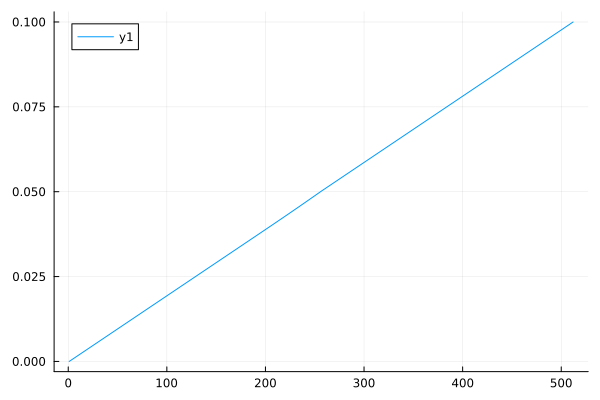

In [76]:
plot(A \ rhs[1:p.N])

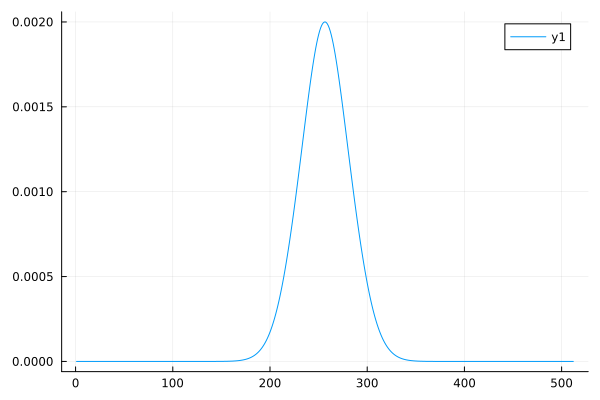

In [71]:
plot(D \ rhs[p.N+1:2*p.N])

In [72]:
sol = M \ rhs

1024-element Vector{Float64}:
 7.782318757703381e-18
 0.004611562429764899
 0.00037138372216677726
 0.004982946151931668
 0.0007427674443335468
 0.005354329874098437
 0.001114151166500316
 0.005725713596265207
 0.0014855348886670856
 0.006097097318431977
 0.0018569186108338559
 0.0064684810405987465
 0.002228302333000626
 ⋮
 0.0004425892981583149
 0.004868482279741464
 0.0004425892981583149
 0.004868482279741464
 0.0004425892981583149
 0.004868482279741464
 0.0004425892981583149
 0.004868482279741464
 0.0004425892981583149
 0.004868482279741464
 0.0004425892981583149
 0.004868482279741464

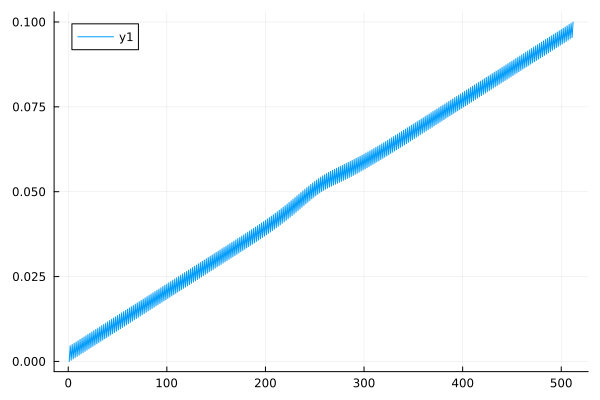

In [73]:
plot(sol[1:p.N])

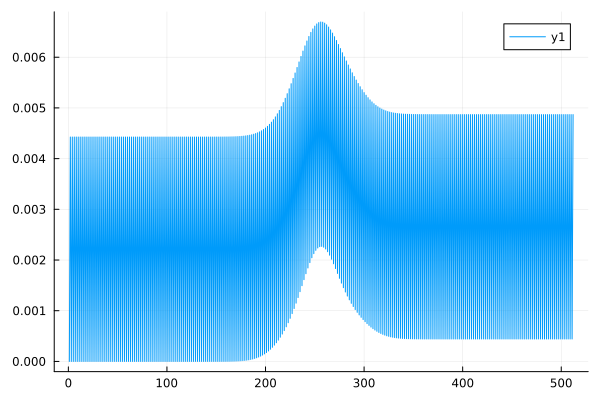

In [74]:
plot(sol[p.N+1:2*p.N])

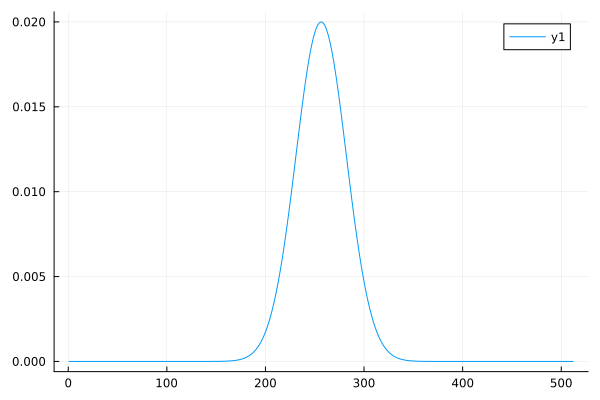

In [134]:
plot(d)